# Smartphone_sales_ Analysis

## About Dataset:

This dataset provides detailed information about various smartphones, including their brand, model, specifications such as RAM and storage capacity, color options, carrier lock status, and final sale prices after discounts.

## Column Descriptions

1.Smartphone: A detailed description of the smartphone's full name, model, and specifications (such as RAM, storage capacity).

2.Brand: The manufacturer brand of the smartphone (e.g., Realme, Samsung, Motorola).

3.Model: The model name or number of the smartphone (e.g., C55, Galaxy M23).

4.RAM: The amount of RAM (in GB) that the smartphone has, which affects its multitasking performance.

5.Storage: The internal storage capacity of the smartphone (in GB). This represents the space available for storing apps, photos, and other files.

6.Color: The color of the smartphone (e.g., Yellow, Blue, Gray, White).

7.Free: Information indicating whether the smartphone is tied to a carrier. "Yes" means the phone is "SIM-free" or unlocked, allowing it to be used with any carrier.

8.Final Price: The final sale price of the smartphone, representing the ultimate cost after discounts or promotions.

## **智慧型手機價格分析**

## ** 研究問題與目標**
本分析的目標是探討智慧型手機的價格影響因素，並透過數據分析來回答以下兩個核心問題：

### **1️⃣ 價格與規格的關聯性分析**
- RAM 和 Storage 是否影響 Final Price？
- 哪個變數對價格的影響更大？
- 是否有明顯的價格分佈趨勢？

### **2️⃣ 品牌的價格影響分析**
- 不同品牌的平均價格是否有明顯差異？
- 哪些品牌主打高端市場，哪些品牌專注於中低價市場？
- 哪些品牌的手機型號最受市場歡迎？

# Importing libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv('/Users/xujiahong/desktop/smartphones.csv')

In [3]:
df.head()

,Smartphone,Brand,Model,RAM,Storage,Color,Free,Final Price
0,Realme C55 8/256GB Sunshower Libre,Realme,C55,8.0,256.0,Yellow,Yes,231.60
1,Samsung Galaxy M23 5G 4/128GB Azul Libre,Samsung,Galaxy M23,4.0,128.0,Blue,Yes,279.00
2,Motorola Moto G13 4/128GB Azul Lavanda Libre,Motorola,Moto G13,4.0,128.0,Blue,Yes,179.01
3,Xiaomi Redmi Note 11S 6/128GB Gris Libre,Xiaomi,Redmi Note 11S,6.0,128.0,Gray,Yes,279.99
4,Nothing Phone (2) 12/512GB Blanco Libre,Nothing,Phone (2),12.0,512.0,White,Yes,799.00


In [4]:
df1 = df.copy()

In [5]:
df.size

14528

In [6]:
df.shape

(1816, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Smartphone   1816 non-null   object 
 1   Brand        1816 non-null   object 
 2   Model        1816 non-null   object 
 3   RAM          1333 non-null   float64
 4   Storage      1791 non-null   float64
 5   Color        1816 non-null   object 
 6   Free         1816 non-null   object 
 7   Final Price  1816 non-null   float64
dtypes: float64(3), object(5)
memory usage: 113.6+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RAM,1333.0,5.960990,2.668070,1.00,4.00,6.00,8.0000,12.00
Storage,1791.0,162.652150,139.411605,2.00,64.00,128.00,256.0000,1000.00
Final Price,1816.0,492.175573,398.606183,60.46,200.99,349.99,652.7175,2271.28


In [9]:
df.isnull().sum()

Smartphone       0
Brand            0
Model            0
RAM            483
Storage         25
Color            0
Free             0
Final Price      0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df['RAM'].fillna(df['RAM'].median(), inplace = True)
df['Storage'].fillna(df['Storage'].median(), inplace = True)

missing_values_filling = df[['RAM','Storage']].isnull().sum()
missing_values_filling

RAM        0
Storage    0
dtype: int64

# Determining Categoric & Numeric Columns

caregoric columns

In [12]:
cat_cols = [col for col in df.columns if str(df[col].dtypes) in ["object", "category", "bool"]]
cat_cols

['Smartphone', 'Brand', 'Model', 'Color', 'Free']

numeric columns

In [13]:
num_cols = [col for col in df.columns if col not in cat_cols]
num_cols

['RAM', 'Storage', 'Final Price']

info about cat_cols

In [14]:
def cat_summary(dataframe, col_name):
    print(pd.DataFrame({
        col_name: dataframe[col_name].value_counts(),
        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)
        
    }))
    print("---------------------------------------------------------")

for col in cat_cols:
    cat_summary(df, col)

                                                  Smartphone     Ratio
Realme C55 8/256GB Sunshower Libre                         1  0.055066
Samsung Galaxy A53 5G 8/256GB Azul Libre                   1  0.055066
Huawei P30 Pro 8/128GB Breathing Crystal Libre             1  0.055066
Huawei Nova 10 8/128GB Plata Libre                         1  0.055066
Samsung Galaxy A21s 3/32GB Negro Libre                     1  0.055066
...                                                      ...       ...
Samsung Galaxy Note 10 Plus 256GB Blanco Libre             1  0.055066
Cubot P80 8/256GB Morado Libre                             1  0.055066
Huawei P30 Pro 8/128GB Black Libre                         1  0.055066
Apple iPhone XS Max 256Gb Gris Espacial Libre              1  0.055066
Xiaomi Redmi Note 9S 6/128GB Dual SIM Gris Libre           1  0.055066

[1816 rows x 2 columns]
---------------------------------------------------------
            Brand      Ratio
Samsung       458  25.220264
Xiaomi 

In [15]:
df.sample()

,Smartphone,Brand,Model,RAM,Storage,Color,Free,Final Price
713,Xiaomi PocoPhone F3 5G 8/256GB Plata Lunar Libre,Xiaomi,PocoPhone F3,8.0,256.0,Silver,Yes,369.0


# Oranizing Columns

In [16]:
df.columns

Index(['Smartphone', 'Brand', 'Model', 'RAM', 'Storage', 'Color', 'Free',
       'Final Price'],
      dtype='object')

In [17]:
df.columns.str.lower()

Index(['smartphone', 'brand', 'model', 'ram', 'storage', 'color', 'free',
       'final price'],
      dtype='object')

In [18]:
df.columns = df.columns.str.lower()

In [19]:
df.columns

Index(['smartphone', 'brand', 'model', 'ram', 'storage', 'color', 'free',
       'final price'],
      dtype='object')

In [20]:
df.columns = ['smartphone','brand','model','ram','storage', 'color', 'free', 'final_price']

drop the smartphone columns because other features already hold this infos

In [21]:
df.drop(columns = "smartphone", axis = 0 , inplace = True)

In [22]:
df.head()

,brand,model,ram,storage,color,free,final_price
0,Realme,C55,8.0,256.0,Yellow,Yes,231.60
1,Samsung,Galaxy M23,4.0,128.0,Blue,Yes,279.00
2,Motorola,Moto G13,4.0,128.0,Blue,Yes,179.01
3,Xiaomi,Redmi Note 11S,6.0,128.0,Gray,Yes,279.99
4,Nothing,Phone (2),12.0,512.0,White,Yes,799.00


In [23]:
df['free'].unique()

array(['Yes', 'No'], dtype=object)

In [24]:
df['free'].value_counts()

Yes    1772
No       44
Name: free, dtype: int64

In [25]:
df[df.free == "No"].shape

(44, 7)

In [26]:
df[df.free == "Yes"].shape

(1772, 7)

In [27]:
df.model.nunique()

383

In [28]:
df.ram.value_counts()

6.0     742
8.0     381
4.0     380
3.0     112
12.0    109
2.0      88
1.0       4
Name: ram, dtype: int64

# Duplicated columns

In [29]:
df.duplicated().sum()

17

In [30]:
df.drop_duplicates(inplace = True)

In [31]:
df.duplicated().sum()

0

# NaN Value

In [32]:
df.isnull().sum()

brand          0
model          0
ram            0
storage        0
color          0
free           0
final_price    0
dtype: int64

# Data visualiztion

In [33]:
df.columns

Index(['brand', 'model', 'ram', 'storage', 'color', 'free', 'final_price'], dtype='object')

### most sold brands

In [34]:
number_of_sold_brd = df.groupby("brand").count().iloc[:,1].reset_index(name = "count").sort_values(by = "count",ascending= False)
number_of_sold_brd

,brand,count
29,Samsung,449
35,Xiaomi,348
1,Apple,291
27,Realme,116
23,OPPO,92
25,POCO,67
15,Huawei,57
20,Motorola,55
32,TCL,36
7,Cubot,33


In [36]:
top5 = number_of_sold_brd[0:6]
top5

,brand,count
29,Samsung,449
35,Xiaomi,348
1,Apple,291
27,Realme,116
23,OPPO,92
25,POCO,67


In [37]:
numeric_df = df.select_dtypes(include = 'number')

In [38]:
numeric_df.sample()

,ram,storage,final_price
1253,6.0,128.0,339.01


In [39]:
df.select_dtypes(include = 'number').columns

Index(['ram', 'storage', 'final_price'], dtype='object')

## 價格與規格的關係分析
## Exploring the Impact of Ram and Storage on Smartphone Pricing
RAM 是否影響手機價格？

Storage是否比Ram更影響價格?

RAM和Storage之間的關聯？

### Heatmap

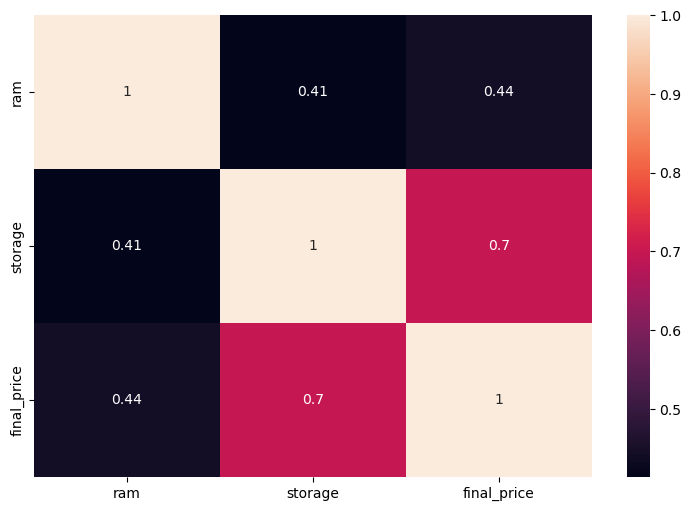

In [40]:
plt.figure(figsize = (9,6))
sns.heatmap(numeric_df.corr(), annot = True)
plt.show()

This heatmap shows that both RAM and storage have a positive impact on price:

The correlation between RAM and price is 0.44, indicating that RAM influences price, but not as strongly as storage.
The correlation between storage and price is 0.70, suggesting that storage capacity has a stronger effect on pricing decisions.
Additionally, there is a moderate positive relationship (0.41) between RAM and storage, meaning that higher RAM smartphones tend to have higher storage, but this relationship is not very strong.
These insights indicate that while RAM contributes to price variations, storage is a more significant factor in determining smartphone prices.

### Pairplot

<Figure size 900x600 with 0 Axes>

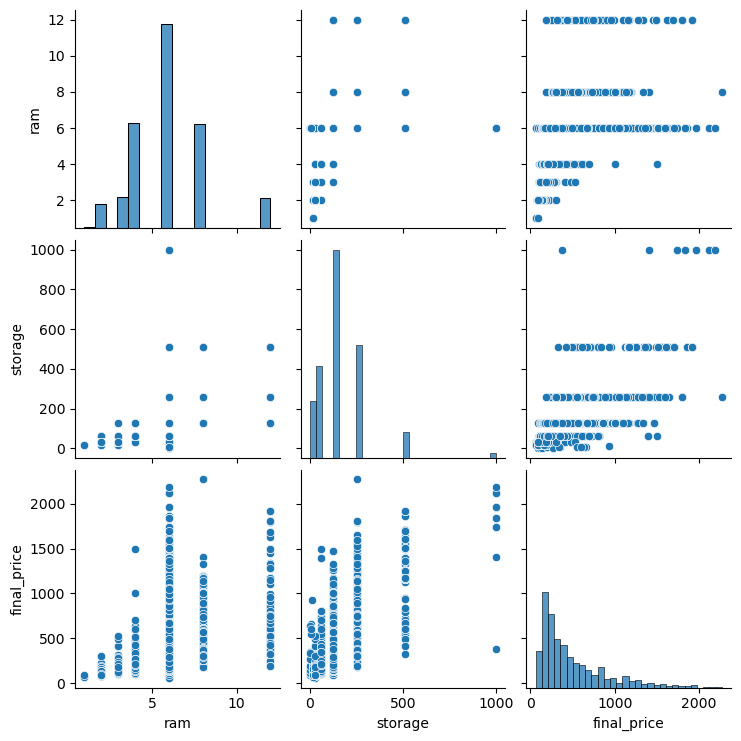

In [41]:
plt.figure(figsize = (9,6))
sns.pairplot(numeric_df)
plt.show()

### Hisplot

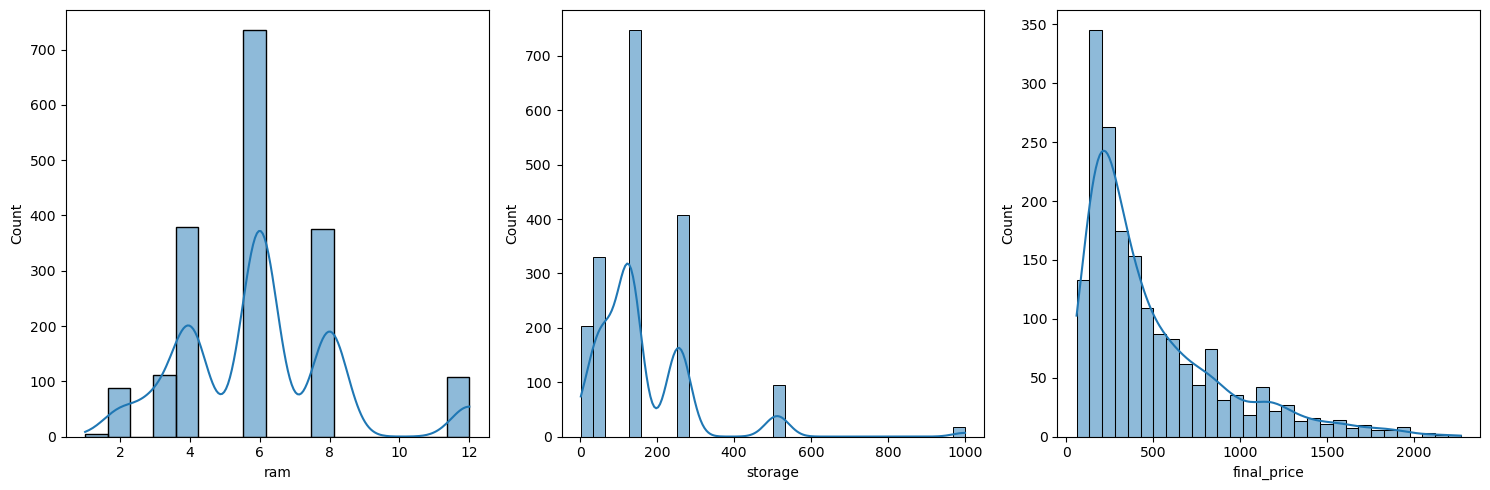

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(x="ram", data=df, kde = True ,ax=axes[0])

sns.histplot(x="storage", data=df, kde = True, ax=axes[1])

sns.histplot(x="final_price", data=df, kde = True, ax=axes[2])

plt.tight_layout()

plt.show()

### Display the relationship between RAM - Final_price and storage - Final_price

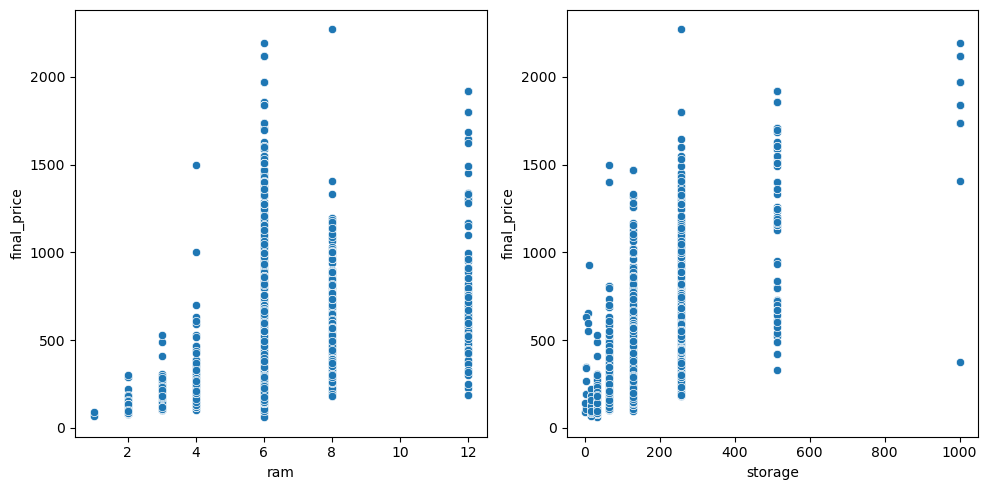

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(x="ram",y="final_price" ,data=df ,ax=axes[0])

sns.scatterplot(x="storage",y="final_price" ,data=df,  ax=axes[1])

plt.tight_layout()

plt.show()

## 品牌的價格與影響

Brands by Count

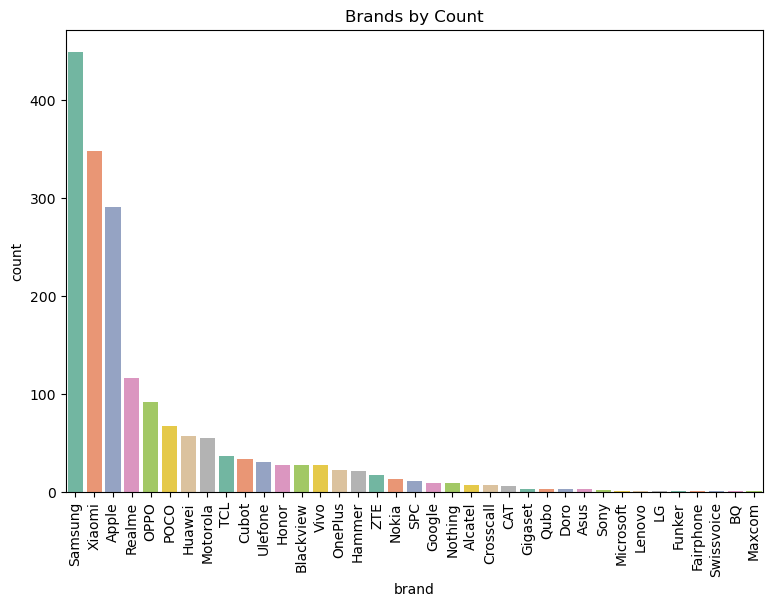

In [44]:
plt.figure(figsize = (9,6))
sns.barplot(x="brand",y="count",data=number_of_sold_brd, palette= "Set2")
plt.xticks(rotation=90)
plt.title("Brands by Count")
plt.show()

TOP 5 Brands

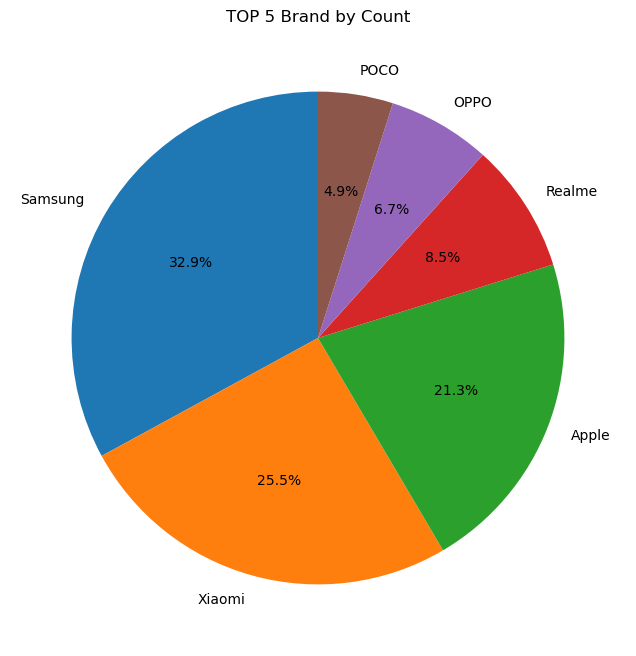

In [47]:
plt.figure(figsize = (8,8))
plt.pie(top5["count"],labels = top5["brand"],autopct = '%1.1f%%',startangle = 90)
plt.title("TOP 5 Brand by Count")
plt.show()

TOP 10 MODEL

In [48]:
number_of_sld_model = df.groupby("model").count().iloc[:,1].reset_index(name = "count").sort_values(by="count",ascending=False)

top_10_model = number_of_sld_model[0:11]

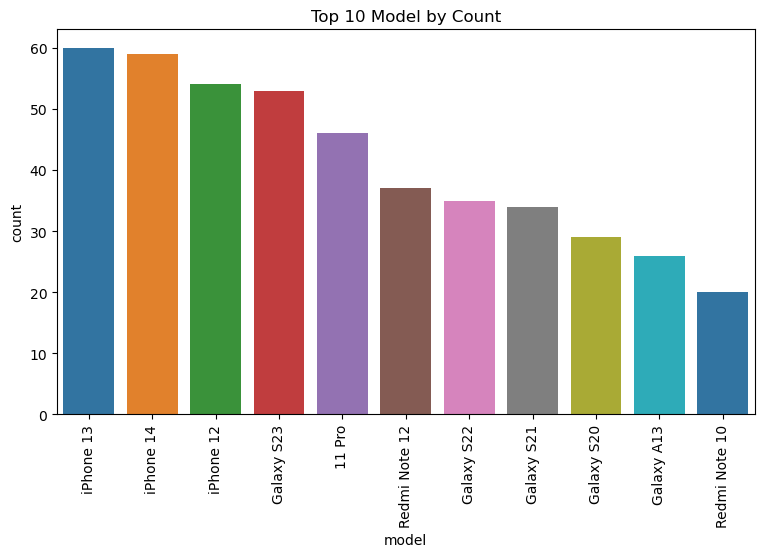

In [49]:
plt.figure(figsize=(9, 5))

sns.barplot(x="model", y="count", data=top_10_model,palette="tab10")

plt.title("Top 10 Model by Count")

plt.xticks(rotation=90)

plt.show()

Brands by AVG Final Price

In [50]:
grp_price = df.groupby("brand")["final_price"].mean().reset_index(name = "mean").sort_values(by="mean",ascending=False)

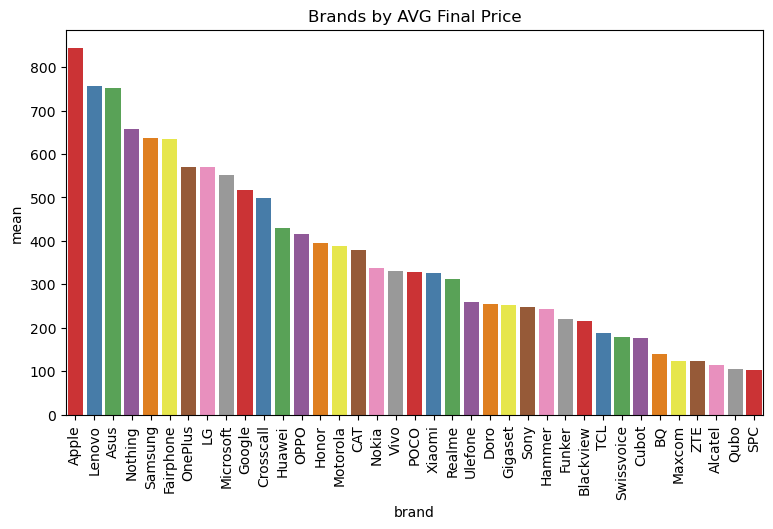

In [56]:
plt.figure(figsize=(9,5))

sns.barplot(x="brand",y="mean",data=grp_price, palette = "Set1")

plt.xticks(rotation=90)

plt.title("Brands by AVG Final Price")

plt.show()

Apple、Samsung、Google、OnePlus 等品牌主打中高端市場，平均售價較高。
Xiaomi、Realme、POCO 則以中低價市場為主，強調高性價比。
ZTE、Alcatel、Cubot 這類品牌價格最低，可能專注於預算型機型或特定市場。

Display colors of Phones

In [53]:
colors = df.groupby("color").count().iloc[:,1].reset_index(name = "count").sort_values(by = "count",ascending=False)

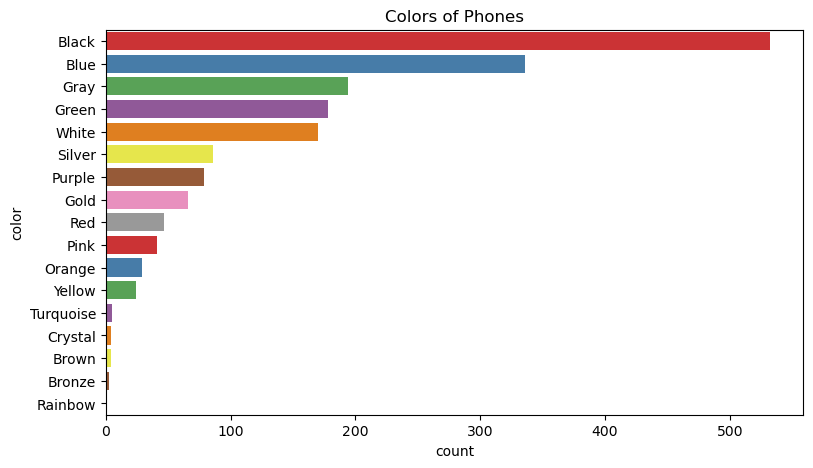

In [55]:
plt.figure(figsize=(9,5))
sns.barplot(x="count",y="color",data=colors,palette= "Set1")
plt.title("Colors of Phones")
plt.show()

## 總結
#### 規格對價格的影響
RAM 和儲存空間是影響手機價格的重要因素，但並非唯一決定因素。價格還受到 品牌、設計、行銷策略等因素的影響，因此同樣的規格可能因品牌溢價而售價不同。

#### 品牌的市場定位

高端品牌（如 Apple、Samsung）平均售價較高，品牌溢價效應明顯，消費者為品牌與生態系統支付更高價格。
平價品牌（如 Xiaomi、Realme）透過 低價高規格策略搶占市場，主打性價比來吸引消費者。
#### 價格分佈趨勢
數據顯示，市場上的高價手機數量較少，而大多數手機價格集中在中低價位區間，顯示大部分消費者仍偏好價格較親民的機型。

## 建議
#### 對於價格策略：

品牌應該提供多種儲存版本（如 128GB、256GB、512GB），以覆蓋不同預算的消費者，提升市場競爭力。
#### 對於市場競爭：

中低價品牌 應持續專注於 高性價比規格配置，並透過行銷強化品牌形象，以吸引更廣泛的消費市場。
高端品牌 應強化品牌價值，例如透過 技術創新、設計、軟體生態 來維持高價定位，確保市場競爭優勢。
